In [211]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [3]:
teams = pd.read_csv('data/starters_by_season.csv')

In [4]:
teams.head()

,season,team,QB1,RB1,FB1,WR1,WR2,TE1,OL1,OL2,...,DL4,LB1,LB2,LB3,DB1,DB2,DB3,DB4,PK1,P1
0,2015,Wyoming,3.0,3.0,NaN,3.0,2.0,2.0,2.0,2.0,...,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,0.0
1,2015,Wisconsin,4.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,...,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,NaN
2,2015,Western Michigan,3.0,3.0,0.0,3.0,3.0,2.0,3.0,3.0,...,2.0,3.0,2.0,2.0,4.0,3.0,3.0,3.0,NaN,2.0
3,2015,Western Kentucky,NaN,3.0,0.0,2.0,2.0,2.0,3.0,2.0,...,2.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,NaN,2.0
4,2015,West Virginia,3.0,5.0,0.0,4.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,2.0,NaN


In [5]:
games = pd.read_csv('data/game_data.csv')

/var/folders/sq/6vts8v4d14n3r_m4sp3mn19w0000gn/T/ipykernel_11575/1101918427.py:1: DtypeWarning: Columns (0: highlights) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv('data/game_data.csv')


In [6]:
games.head()

,id,season,week,seasonType,startDate,startTimeTBD,completed,neutralSite,conferenceGame,attendance,...,awayClassification,awayConference,awayPoints,awayLineScores,awayPostgameWinProbability,awayPregameElo,awayPostgameElo,excitementIndex,highlights,notes
0,400795501,2015,1,regular,2015-08-29T19:30:00.000Z,False,True,False,False,NaN,...,fcs,MVFC,35.0,"[7, 21, 0, 7]",NaN,NaN,NaN,NaN,NaN,NaN
1,400603840,2015,1,regular,2015-09-03T22:00:00.000Z,False,True,True,False,51664.0,...,fbs,ACC,13.0,"[7, 6, 0, 0]",0.677541,1477.0,1477.0,7.949786,NaN,NaN
2,400763593,2015,1,regular,2015-09-03T22:00:00.000Z,False,True,False,False,39184.0,...,fbs,Conference USA,15.0,"[3, 0, 6, 6]",0.898683,1321.0,1338.0,5.390338,NaN,NaN
3,400799035,2015,1,regular,2015-09-03T23:00:00.000Z,False,True,False,False,NaN,...,fcs,Southland,16.0,"[7, 6, 0, 3]",NaN,NaN,NaN,NaN,NaN,NaN
4,400795766,2015,1,regular,2015-09-03T23:00:00.000Z,False,True,False,False,NaN,...,ii,Independent DII,12.0,"[0, 0, 6, 6]",NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
games.homeTeam.head()

0           Montana
1    South Carolina
2               UCF
3           Samford
4      Murray State
Name: homeTeam, dtype: str

In [8]:
games.awayTeam.head()

0       North Dakota State
1           North Carolina
2    Florida International
3         Central Arkansas
4        Kentucky Wesleyan
Name: awayTeam, dtype: str

In [9]:
games.season.head()

0    2015
1    2015
2    2015
3    2015
4    2015
Name: season, dtype: int64

# Null Values

Fill null values in rosters with 0.0 indicating either no player at that position, or unranked player

Identify games that have participating teams that are missing a roster in the roster dataset. Remove those games from the dataset.

In [10]:
teams = teams.fillna(0.0)

In [11]:
teams.info()

<class 'pandas.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   season  2725 non-null   int64  
 1   team    2725 non-null   str    
 2   QB1     2725 non-null   float64
 3   RB1     2725 non-null   float64
 4   FB1     2725 non-null   float64
 5   WR1     2725 non-null   float64
 6   WR2     2725 non-null   float64
 7   TE1     2725 non-null   float64
 8   OL1     2725 non-null   float64
 9   OL2     2725 non-null   float64
 10  OL3     2725 non-null   float64
 11  OL4     2725 non-null   float64
 12  OL5     2725 non-null   float64
 13  DL1     2725 non-null   float64
 14  DL2     2725 non-null   float64
 15  DL3     2725 non-null   float64
 16  DL4     2725 non-null   float64
 17  LB1     2725 non-null   float64
 18  LB2     2725 non-null   float64
 19  LB3     2725 non-null   float64
 20  DB1     2725 non-null   float64
 21  DB2     2725 non-null   float64
 22  DB3     272

In [12]:
missing_teams = []

for _, game in games.iterrows():
    season = game.season
    home = game.homeTeam
    away = game.awayTeam

    if len(teams[(teams['season'] == season) & (teams['team'] == home)]) < 1:
        missing_teams.append((season, home))

    if len(teams[(teams['season'] == season) & (teams['team'] == away)]) < 1:
        missing_teams.append((season,away))

In [13]:
missing_teams = set(missing_teams)

In [14]:
missing_df = pd.DataFrame(missing_teams, columns=["season", "team"])

In [15]:
games["home_key"] = list(zip(games["season"], games["homeTeam"]))
games["away_key"] = list(zip(games["season"], games["awayTeam"]))

In [16]:
games_clean = games[
    ~games["home_key"].isin(missing_teams) &
    ~games["away_key"].isin(missing_teams)
]

In [17]:
games_clean.head()

,id,season,week,seasonType,startDate,startTimeTBD,completed,neutralSite,conferenceGame,attendance,...,awayPoints,awayLineScores,awayPostgameWinProbability,awayPregameElo,awayPostgameElo,excitementIndex,highlights,notes,home_key,away_key
0,400795501,2015,1,regular,2015-08-29T19:30:00.000Z,False,True,False,False,NaN,...,35.0,"[7, 21, 0, 7]",NaN,NaN,NaN,NaN,NaN,NaN,"(2015, Montana)","(2015, North Dakota State)"
1,400603840,2015,1,regular,2015-09-03T22:00:00.000Z,False,True,True,False,51664.0,...,13.0,"[7, 6, 0, 0]",0.677541,1477.0,1477.0,7.949786,NaN,NaN,"(2015, South Carolina)","(2015, North Carolina)"
2,400763593,2015,1,regular,2015-09-03T22:00:00.000Z,False,True,False,False,39184.0,...,15.0,"[3, 0, 6, 6]",0.898683,1321.0,1338.0,5.390338,NaN,NaN,"(2015, UCF)","(2015, Florida International)"
3,400799035,2015,1,regular,2015-09-03T23:00:00.000Z,False,True,False,False,NaN,...,16.0,"[7, 6, 0, 3]",NaN,NaN,NaN,NaN,NaN,NaN,"(2015, Samford)","(2015, Central Arkansas)"
6,400756896,2015,1,regular,2015-09-03T23:00:00.000Z,False,True,False,False,27126.0,...,3.0,"[0, 0, 3, 0]",0.000014,NaN,NaN,2.087296,NaN,NaN,"(2015, Wake Forest)","(2015, Elon)"


In [18]:
games_clean.columns

Index(['id', 'season', 'week', 'seasonType', 'startDate', 'startTimeTBD',
       'completed', 'neutralSite', 'conferenceGame', 'attendance', 'venueId',
       'venue', 'homeId', 'homeTeam', 'homeClassification', 'homeConference',
       'homePoints', 'homeLineScores', 'homePostgameWinProbability',
       'homePregameElo', 'homePostgameElo', 'awayId', 'awayTeam',
       'awayClassification', 'awayConference', 'awayPoints', 'awayLineScores',
       'awayPostgameWinProbability', 'awayPregameElo', 'awayPostgameElo',
       'excitementIndex', 'highlights', 'notes', 'home_key', 'away_key'],
      dtype='str')

# Target Engineering

Home Win == 1.0

Away Win == 0.0

Ties -> Drop (Only 7 instances in the dataset)

In [19]:
games_clean = games_clean[games_clean.homePoints != games_clean.awayPoints]

In [20]:
games_clean["target"] = (games_clean["homePoints"] > games_clean["awayPoints"]).astype(int)

# Feature Engineering

- QB_Diff: (QB_H - QB_A)
- OL_adv_H: (OL_avg_H - DL_avg_A)
- OL_adv_A: (OL_avg_A - DL_avg_H)
- WR_adv_H: (WR_avg_H - DB_avg_A)
- WR_adv_A: (WR_avg_A - DB_avg_H)
- RB_adv_H: (RB_H - LB_avg_A)
- RB_adv_A: (RB_A - LB_avg_H)
- TE_Diff: (TE_H - TE_A)
- PK_Diff: (PK_H - PK_A)
- P_Diff: (P_H - P_A)

In [21]:
OL_group = [f'OL{i}' for i in range(1,6)]
WR_group = [f'WR{i}' for i in range(1,3)]
DL_group = [f'DL{i}' for i in range(1,5)]
LB_group = [f'LB{i}' for i in range(1,4)]
DB_group = [f'DB{i}' for i in range(1,5)]

In [22]:
teams['OL_avg'] = teams[OL_group].mean(axis=1)
teams['WR_avg'] = teams[WR_group].mean(axis=1)
teams['DL_avg'] = teams[DL_group].mean(axis=1)
teams['LB_avg'] = teams[LB_group].mean(axis=1)
teams['DB_avg'] = teams[DB_group].mean(axis=1)

features = ['QB_diff',
            'OL_adv_H',
            'OL_adv_A',
            'WR_adv_H',
            'WR_adv_A',
            'RB_adv_H',
            'RB_adv_A',
            'TE_diff',
            'PK_diff',
            'P_diff']

X = []
for year, home, away, target in games_clean[['season','homeTeam','awayTeam','target']].itertuples(index=False):
    X_g = {}
    home_roster = teams[(teams.season == year) & (teams.team == home)]
    away_roster = teams[(teams.season == year) & (teams.team == away)]

    X_g['QB_diff'] = home_roster.QB1.iloc[0] - away_roster.QB1.iloc[0]
    X_g['OL_adv_H'] = home_roster.OL_avg.iloc[0] - away_roster.DL_avg.iloc[0]
    X_g['OL_adv_A'] = away_roster.OL_avg.iloc[0] - home_roster.DL_avg.iloc[0]
    X_g['WR_adv_H'] = home_roster.WR_avg.iloc[0] - away_roster.DB_avg.iloc[0]
    X_g['WR_adv_A'] = away_roster.WR_avg.iloc[0] - home_roster.DB_avg.iloc[0]
    X_g['RB_adv_H'] = home_roster.RB1.iloc[0] - away_roster.LB_avg.iloc[0]
    X_g['RB_adv_A'] = away_roster.RB1.iloc[0] - home_roster.LB_avg.iloc[0]
    X_g['TE_diff'] = home_roster.TE1.iloc[0] - away_roster.TE1.iloc[0]
    X_g['PK_diff'] = home_roster.PK1.iloc[0] - away_roster.PK1.iloc[0]
    X_g['P_diff'] = home_roster.P1.iloc[0] - away_roster.P1.iloc[0]
    X_g['season'] = year
    X_g['home'] = home
    X_g['away'] = away
    X_g['target'] = target

    X.append(X_g)

Xy = pd.DataFrame(X)
    

In [133]:
features = ['QB_diff',
            'OL_adv_1',
            'OL_adv_2',
            'WR_adv_1',
            'WR_adv_2',
            'RB_adv_1',
            'RB_adv_2',
            'TE_diff',
            'PK_diff',
            'P_diff',
            'QB1_vs_DB_2',
            'QB2_vs_DB_1',
            'PASS_SYNERGY_diff',
            'team_1_is_home']

In [125]:
def build_matchup_row(year, team_1, team_2, team_1_is_home, team_1_won, teams):
    t1 = teams[(teams.season == year) & (teams.team == team_1)]
    t2 = teams[(teams.season == year) & (teams.team == team_2)]

    team_1_synergy = (
        2.0 * t1.QB1.iloc[0] +
        1.0 * t1.WR_avg.iloc[0] +
        0.8 * t1.TE1.iloc[0]
        ) / 3.8

    team_2_synergy = (
        2.0 * t2.QB1.iloc[0] +
        1.0 * t2.WR_avg.iloc[0] +
        0.8 * t2.TE1.iloc[0]
         ) / 3.8

    return {
        'QB_diff': t1.QB1.iloc[0] - t2.QB1.iloc[0],
        'OL_adv_1': t1.OL_avg.iloc[0] - t2.DL_avg.iloc[0],
        'OL_adv_2': t2.OL_avg.iloc[0] - t1.DL_avg.iloc[0],
        'WR_adv_1': t1.WR_avg.iloc[0] - t2.DB_avg.iloc[0],
        'WR_adv_2': t2.WR_avg.iloc[0] - t1.DB_avg.iloc[0],
        'RB_adv_1': t1.RB1.iloc[0] - t2.LB_avg.iloc[0],
        'RB_adv_2': t2.RB1.iloc[0] - t1.LB_avg.iloc[0],
        'TE_diff': t1.TE1.iloc[0] - t2.TE1.iloc[0],
        'PK_diff': t1.PK1.iloc[0] - t2.PK1.iloc[0],
        'P_diff': t1.P1.iloc[0] - t2.P1.iloc[0],
        'QB1_vs_DB_2': t1.QB1.iloc[0] - t2.DB_avg.iloc[0],
        'QB2_vs_DB_1': t2.QB1.iloc[0] - t1.DB_avg.iloc[0],
        'PASS_SYNERGY_diff': team_1_synergy - team_2_synergy,
        'team_1_is_home': team_1_is_home,
        'season': year,
        'team_1': team_1,
        'team_2': team_2,
        'target': team_1_won,
    }

In [126]:
def build_xy(df, train=True):
    rows = []

    for year, home, away, home_won in df[['season', 'homeTeam', 'awayTeam', 'target']].itertuples(index=False):
        rows.append(build_matchup_row(year, home, away, 1, home_won, teams))
        if train:
            rows.append(build_matchup_row(year, away, home, 0, 1 - home_won, teams))

    Xy = pd.DataFrame(rows)

    return Xy

Xy.head()

# Train Test Split

Using 2025 as test

In [167]:
train_years = [year for year in range(2021, 2025)]
test_years = [2025]

In [168]:
train_raw_data = games_clean[games_clean.season.isin(train_years)]
test_raw_data = games_clean[games_clean.season.isin(test_years)]

In [169]:
Xy_train = build_xy(train_raw_data)
Xy_test = build_xy(test_raw_data, train=False)

In [170]:
Xy_train.head()

,QB_diff,OL_adv_1,OL_adv_2,WR_adv_1,WR_adv_2,RB_adv_1,RB_adv_2,TE_diff,PK_diff,P_diff,QB1_vs_DB_2,QB2_vs_DB_1,PASS_SYNERGY_diff,team_1_is_home,season,team_1,team_2,target
0,0.0,-1.00,0.30,0.75,0.75,0.666667,0.666667,-1.0,0.0,2.0,0.75,0.75,-0.210526,1,2021,Illinois,Nebraska,1
1,0.0,0.30,-1.00,0.75,0.75,0.666667,0.666667,1.0,0.0,-2.0,0.75,0.75,0.210526,0,2021,Nebraska,Illinois,0
2,-1.0,0.20,0.25,-0.25,-0.25,0.000000,0.000000,0.0,-3.0,0.0,-0.25,0.75,-0.526316,1,2021,Fresno State,UConn,1
3,1.0,0.25,0.20,-0.25,-0.25,0.000000,0.000000,0.0,3.0,0.0,0.75,-0.25,0.526316,0,2021,UConn,Fresno State,0
4,1.0,0.40,-0.95,1.00,-0.75,1.000000,-1.000000,2.0,-1.0,3.0,1.00,-0.75,1.210526,1,2021,UCLA,Hawai'i,1


In [171]:
Xy_test.head()

,QB_diff,OL_adv_1,OL_adv_2,WR_adv_1,WR_adv_2,RB_adv_1,RB_adv_2,TE_diff,PK_diff,P_diff,QB1_vs_DB_2,QB2_vs_DB_1,PASS_SYNERGY_diff,team_1_is_home,season,team_1,team_2,target
0,0.0,0.40,-0.50,0.00,-0.25,0.666667,-0.666667,1.0,0.0,0.0,1.00,0.75,0.210526,1,2025,Kansas State,Iowa State,0
1,0.0,-1.75,0.00,-0.75,-0.75,2.000000,0.000000,0.0,0.0,0.0,2.25,2.25,0.000000,1,2025,Nicholls,Incarnate Word,1
2,3.0,3.00,-3.25,3.25,-4.00,4.000000,-3.666667,3.0,3.0,0.0,2.25,-4.00,3.263158,1,2025,UNLV,Idaho State,1
3,0.0,0.00,0.00,1.50,0.50,2.000000,0.000000,0.0,0.0,0.0,1.50,1.50,0.263158,1,2025,Portland State,Tarleton State,0
4,0.0,-0.10,-0.75,0.50,-0.50,0.000000,1.000000,0.0,0.0,0.0,0.00,-0.50,0.131579,1,2025,Kansas,Fresno State,1


Xy_train = Xy[Xy.season.isin(train_years)]
Xy_test = Xy[Xy.season.isin(test_years)]

In [172]:
X_train = Xy_train[features]
y_train = Xy_train.target
X_test = Xy_test[features]
y_test = Xy_test.target

# Modeling

Logistic Regression

In [173]:
logit = LogisticRegression()

In [174]:
logit.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [175]:
y_preds = logit.predict(X_test)

In [176]:
accuracy_score(y_test, y_preds)

0.6160867084997148

In [177]:
XGBoost = GradientBoostingClassifier()

In [178]:
XGBoost.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [179]:
y_preds = XGBoost.predict(X_test)

In [180]:
accuracy_score(y_test, y_preds)

0.6138049058756417

# Cross Validation

In [181]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "logloss": "neg_log_loss",
    "auc": "roc_auc",
    "accuracy": "accuracy",
}

In [182]:
logit_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

In [183]:
logit_param_grid = [
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
    }
]

In [184]:
logit_search = GridSearchCV(
    estimator=logit_pipe,
    param_grid=logit_param_grid,
    scoring=scoring,
    refit="logloss",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [185]:
logit_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/Users/michaelschoose/SIADS 699/MADS_699_Kemp_Schoose_Thoreux/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/michaelschoose/SIADS 699/MADS_699_Kemp_Schoose_Thoreux/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/michaelschoose/SIADS 699/MADS_699_Kemp_Schoose_Thoreux/venv/lib/python3.12/site-packages/skle

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}, {'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'auc': 'roc_auc', 'logloss': 'neg_log_loss'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'logloss'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",St

In [186]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [187]:
rf_param_grid = {
    "model__n_estimators": [5, 10, 25],
    "model__max_depth": [None, 4, 8, 12],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, None],
}

In [188]:
rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit="logloss",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [189]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 4, ...], 'model__max_features': ['sqrt', 0.5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'auc': 'roc_auc', 'logloss': 'neg_log_loss'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'logloss'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... sh

In [190]:
gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [191]:
gb_param_dist = {
    "model__n_estimators": [5, 10, 25, 100],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.6, 0.8, 1.0],
}

In [192]:
gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_param_dist,
    n_iter=40,
    scoring={
        "logloss": "neg_log_loss",
        "auc": "roc_auc",
        "accuracy": "accuracy"
    },
    refit="logloss",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

In [193]:
gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'auc': 'roc_auc', 'logloss': 'neg_log_loss'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'logloss'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acros

In [197]:
print("LR best params:", logit_search.best_params_)
print("LR best CV logloss:", logit_search.best_score_)

LR best params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
LR best CV logloss: -0.6350675880390065


In [198]:
print("RF best params:", rf_search.best_params_)
print("RF best CV logloss:", rf_search.best_score_)

RF best params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 25}
RF best CV logloss: -0.625378713773647


In [199]:
print("GB best params:", gb_search.best_params_)
print("GB best CV logloss:", gb_search.best_score_)

GB best params: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 3, 'model__learning_rate': 0.1}
GB best CV logloss: -0.6249248575142852


In [200]:
best_model = gb_search.best_estimator_

In [201]:
y_probs = best_model.predict_proba(X_test)[:,1]

In [202]:
auc = roc_auc_score(y_test, y_probs)

In [203]:
y_preds = best_model.predict(X_test)

In [204]:
acc = accuracy_score(y_test, y_preds)

In [205]:
print("Test AUC:", auc)
print("Test Accuracy:", acc)

Test AUC: 0.6340503325146941
Test Accuracy: 0.609811751283514


In [206]:
importances = pd.Series(
    best_model.named_steps['model'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances)

team_1_is_home       0.211156
OL_adv_1             0.147467
OL_adv_2             0.136212
WR_adv_1             0.101501
WR_adv_2             0.093912
PASS_SYNERGY_diff    0.092219
RB_adv_2             0.051838
RB_adv_1             0.049251
QB1_vs_DB_2          0.035110
QB2_vs_DB_1          0.032871
TE_diff              0.024130
QB_diff              0.017349
PK_diff              0.005517
PK_diff              0.001467
dtype: float64


# Analyze incorrect predictions

Test Accuracy: 0.6098
Test ROC AUC: 0.6341

Confusion Matrix:
[[174 494]
 [190 895]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.26      0.34       668
           1       0.64      0.82      0.72      1085

    accuracy                           0.61      1753
   macro avg       0.56      0.54      0.53      1753
weighted avg       0.58      0.61      0.58      1753


Number of incorrect predictions: 684
Total predictions: 1753

False Positives (predicted home win, but home lost): 494
False Negatives (predicted home loss, but home won): 190

Feature statistics for incorrect predictions:
          QB_diff    OL_adv_1    OL_adv_2    WR_adv_1    WR_adv_2    RB_adv_1  \
count  684.000000  684.000000  684.000000  684.000000  684.000000  684.000000   
mean    -0.052632   -0.143202   -0.095102    0.217836    0.302997    0.477096   
std      1.627952    0.837793    0.867682    1.128570    1.166747    1.442447   
min     -4.00000

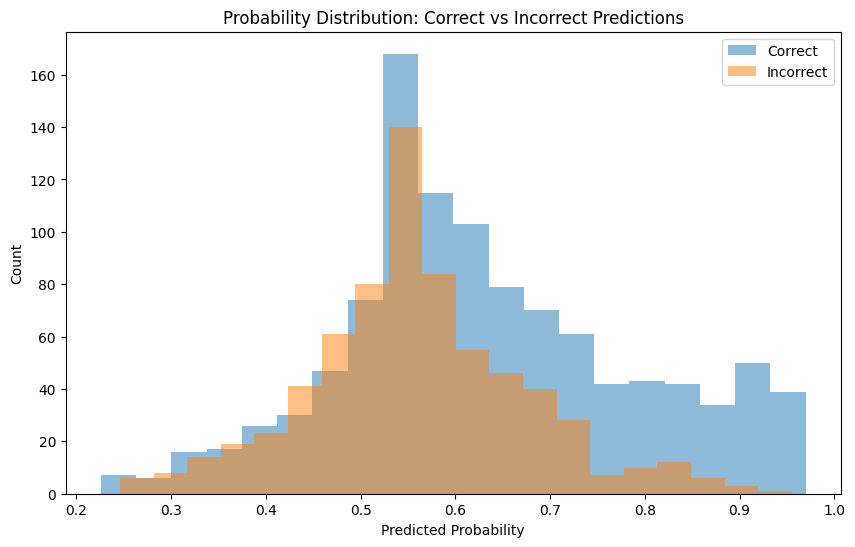


Sample incorrect predictions:
    actual  predicted  probability  QB_diff  OL_adv_1  OL_adv_2  WR_adv_1  \
0        0          1     0.645772      0.0      0.40     -0.50      0.00   
3        0          1     0.549572      0.0      0.00      0.00      1.50   
6        0          1     0.538090      0.0      0.00      0.00      0.00   
7        1          0     0.380848     -1.0     -0.25      0.15      0.50   
13       0          1     0.557016      0.0      0.00      0.00      0.00   
16       0          1     0.529371      0.0      0.05      0.20      1.25   
17       0          1     0.684286      3.0     -2.00      0.00      0.50   
18       1          0     0.462032      3.0     -0.75     -0.15      0.00   
25       0          1     0.547808     -3.0      0.00     -0.90     -0.25   
28       1          0     0.447730     -2.0     -0.75     -1.50      0.00   

    WR_adv_2  RB_adv_1  RB_adv_2  TE_diff  PK_diff  PK_diff  PK_diff  PK_diff  \
0      -0.25  0.666667 -0.666667      1.

In [209]:
# Analyze incorrect predictions

def analyze_incorrect_predictions(model, X_test, y_test, features):
    y_preds = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_probs = model.decision_function(X_test)
    else:
        raise ValueError("Model must support predict_proba or decision_function")

    acc = accuracy_score(y_test, y_preds)
    auc = roc_auc_score(y_test, y_probs)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test ROC AUC: {auc:.4f}\n")

    results_df = X_test.copy()
    results_df['actual'] = y_test
    results_df['predicted'] = y_preds
    results_df['probability'] = y_probs
    results_df['correct'] = results_df['actual'] == results_df['predicted']

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_preds))
    print("\nClassification Report:")
    print(classification_report(y_test, y_preds))

    incorrect = results_df[~results_df['correct']]
    print(f"\nNumber of incorrect predictions: {len(incorrect)}")
    print(f"Total predictions: {len(results_df)}")

    false_positives = incorrect[(incorrect['predicted'] == 1) & (incorrect['actual'] == 0)]
    false_negatives = incorrect[(incorrect['predicted'] == 0) & (incorrect['actual'] == 1)]

    print(f"\nFalse Positives (predicted home win, but home lost): {len(false_positives)}")
    print(f"False Negatives (predicted home loss, but home won): {len(false_negatives)}")

    print("\nFeature statistics for incorrect predictions:")
    print(incorrect[features].describe())

    correct = results_df[results_df['correct']]
    print("\nFeature statistics for correct predictions:")
    print(correct[features].describe())

    plt.figure(figsize=(10, 6))
    plt.hist(results_df[results_df['correct']]['probability'], alpha=0.5, label='Correct', bins=20)
    plt.hist(results_df[~results_df['correct']]['probability'], alpha=0.5, label='Incorrect', bins=20)
    plt.xlabel('Predicted Probability')
    plt.ylabel('Count')
    plt.title('Probability Distribution: Correct vs Incorrect Predictions')
    plt.legend()
    plt.show()

    print("\nSample incorrect predictions:")
    display_cols = ['actual', 'predicted', 'probability'] + features
    print(incorrect.head(10)[display_cols])

    return results_df, incorrect

results_df, incorrect = analyze_incorrect_predictions(best_model, X_test, y_test, features)

In [210]:
cal_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)
cal_model.fit(X_train, y_train)

NameError: name 'CalibratedClassifierCV' is not defined